# Project X -- Vinay Gannamaneni

**TA Help:** (for instance) John Smith, Alice Jones, etc., list names of any TAs who helped you

- For example: Help with figuring out how to write a function (describe the tasks that they helped you with)

**Collaboration:** My Friend in CS, My Uncle, Another Student, etc., list names of any other people who helped you

(describe the tasks that they helped you with)
- For example: helped figuring out how to load the dataset.
- Another example: helped debug error with my plot.

**Internet Resources:** Stack Exchange, Stack Overflow, etc.

(describe any information that you learned from internet resources, including the URLs)
- data frames in Pandas versus R from StackOverflow  https://stackoverflow.com/questions/8991709/why-were-pandas-merges-in-python-faster-than-data-table-merges-in-r-in-2012

**ChatGPT, Gemini, Claude, etc:** Any language models or generative AI chatbots that helped you.

(if you used any such tools, please tell us here)
- For example:  I asked ChatGPT how to define a new data frames
- Another example:  Gemini told me how to make a function for sorting my data

- ***Link to AI Chat History***: Please share a link to your chat if you used AI (ex. ChatGPT Shared Links)
**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

In [2]:
myDF <- read.csv("/anvil/projects/tdm/data/death_records/DeathRecords.csv")
race_decoder <- read.csv("/anvil/projects/tdm/data/death_records/Race.csv")
marital_decoder <- read.csv("/anvil/projects/tdm/data/death_records/MaritalStatus.csv")
day_decoder <- read.csv("/anvil/projects/tdm/data/death_records/DayOfWeekOfDeath.csv")

In [2]:
race_counts <- table(myDF$Race)

Count occurrences of each race code

In [3]:
race_counts_df <- as.data.frame(race_counts)
colnames(race_counts_df) <- c("Code", "Count")
race_info <- merge(race_counts_df, race_decoder, by="Code")

Convert table to dataframe and merge with decoder to get race descriptions

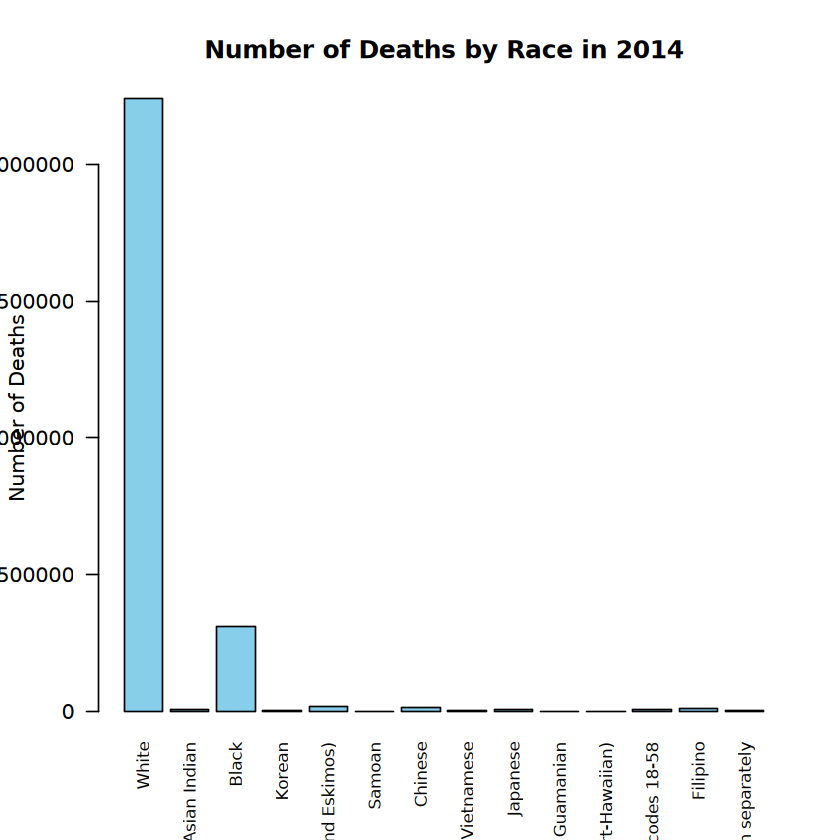

In [4]:
barplot(
  height = race_info$Count,
  names.arg = race_info$Description,
  las = 2,              # Rotate x-axis labels
  col = "skyblue",
  main = "Number of Deaths by Race in 2014",
  ylab = "Number of Deaths",
  cex.names = 0.8       # Reduce label size to fit
)

The Race column contains numeric codes that correspond to different races. Using the decoder Race.csv, these codes can be translated into readable race descriptions like White, Black, Korean, Chinese, Japanese, American Indian, and more. The dataset shows that the number of deaths varies greatly by race, with some races having tens of thousands of entries while others have only a few hundred.

Besides Race, other coded columns such as MaritalStatus and DayOfWeekOfDeath can reveal interesting patterns. For example, analyzing deaths by marital status could show whether married or single people are more represented, and deaths by day of the week might show trends related to accidents or health incidents. Columns like MannerOfDeath, Education, or PlaceOfDeath could also provide useful insights if decoder files exist.

In [5]:
race_info[which.min(race_info$Count), ]

,Code,Count,Description
,<fct>,<int>,<chr>
10,58,316,Guamanian


Race with the smallest number of entires is "Gumanian"

## Question 2

In [6]:
save_df <- myDF[myDF$Race != 1, ]
race_counts_filtered <- table(save_df$Race)

'1' appears 2241510 times which makes the smaller counts nearly invisible on a plot. Excluding this allows better visualization of the other categories.

In [7]:
race_counts_filtered_df <- as.data.frame(race_counts_filtered)
colnames(race_counts_filtered_df) <- c("Code", "Count")
race_info_filtered <- merge(race_counts_filtered_df, race_decoder, by="Code")

Merge with decoder for readable labels

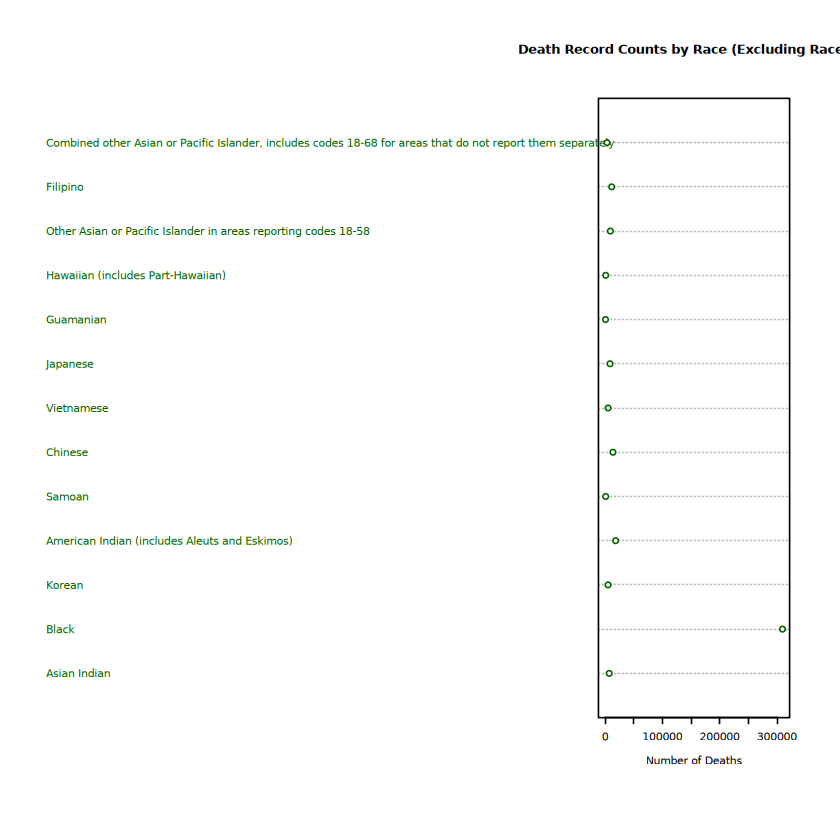

In [8]:
dotchart(
  race_info_filtered$Count,
  labels = race_info_filtered$Description,
  main = "Death Record Counts by Race (Excluding Race '1')",
  xlab = "Number of Deaths",
  cex = 0.5,
  col = "darkgreen"
)

Using dotchart() for better readability

2.1 How did you make your plot(s) unique?
- I used dotchart() instead of a basic plot() or barplot because it better shows small differences in counts between races when one category dominates.
- I filtered out the extremely high-count category (Race '1') to allow the smaller categories to be visible and comparable.

2.2 How did you ensure your plot(s) are readable for others?
- I included readable race names instead of numeric codes by merging with the decoder file.
- I added a descriptive title that specifies which category was excluded, and labeled the x-axis clearly as “Number of Deaths.”
- I adjusted label sizes so that all names are legible.

2.3 What race(s) did you not include and why?
- Race '1' was excluded because it had a disproportionately high number of entries (2241510), which made other categories almost invisible in the plot.

## Question 3

In [9]:
marital_decoder

Code,Description
<chr>,<chr>
S,"Never married, single"
M,Married
W,Widowed
D,Divorced
U,Marital Status unknown


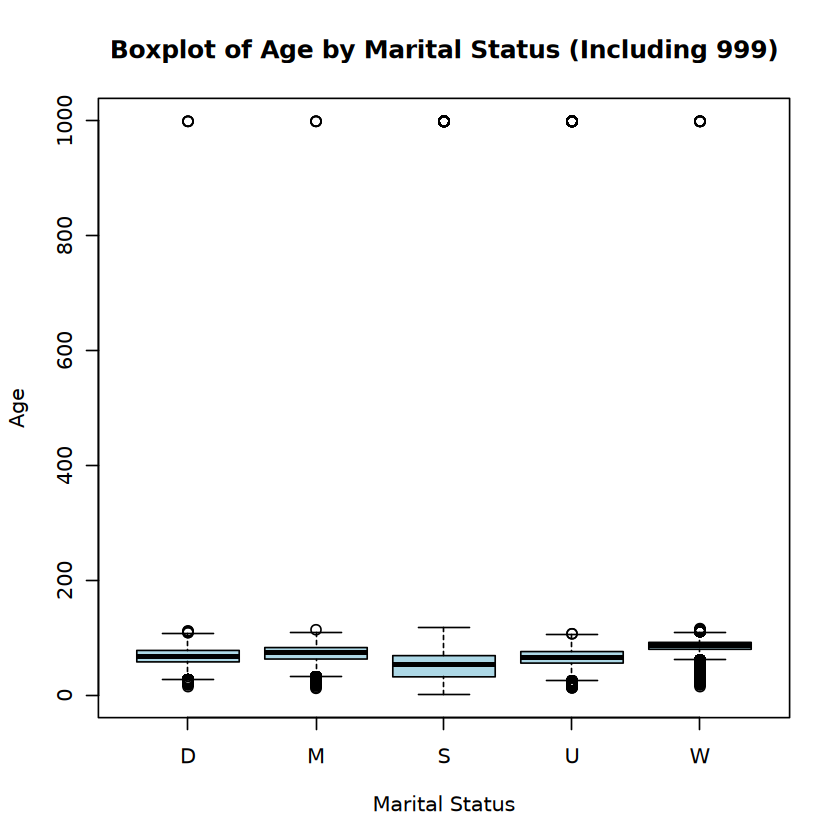

In [10]:
boxplot(Age ~ MaritalStatus, data = myDF,
        main = "Boxplot of Age by Marital Status (Including 999)",
        xlab = "Marital Status",
        ylab = "Age",
        col = "lightblue")

Observation: The age '999' will appear as extreme outliers, compressing the rest of the plot.

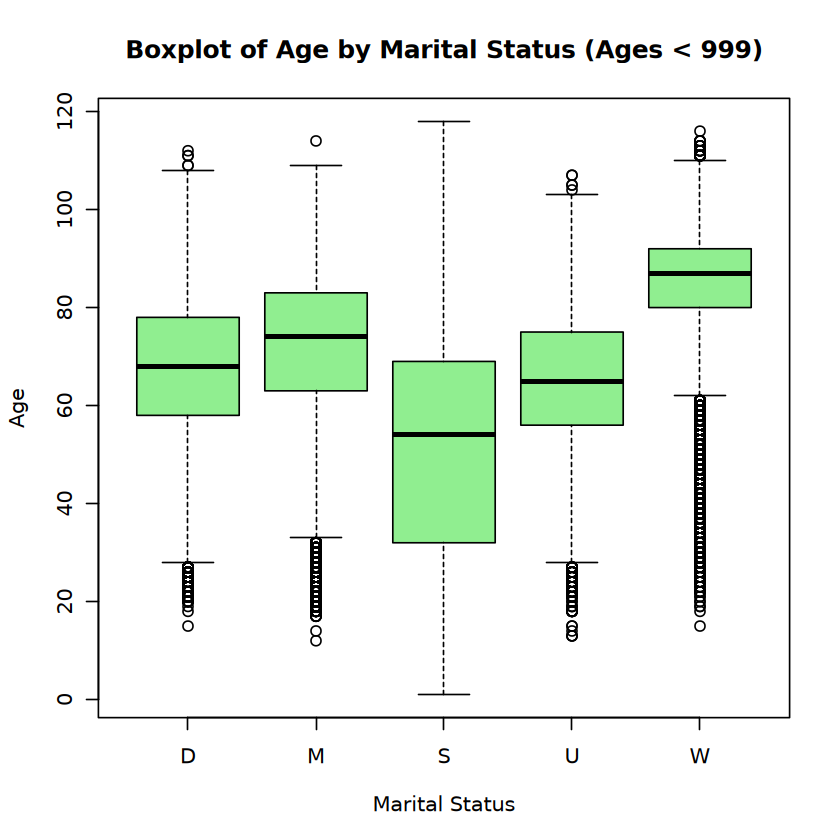

In [11]:
cleanDF <- myDF[myDF$Age != 999, ]
boxplot(Age ~ MaritalStatus, data = cleanDF,
        main = "Boxplot of Age by Marital Status (Ages < 999)",
        xlab = "Marital Status",
        ylab = "Age",
        col = "lightgreen")

Boxplot without the 999 error value

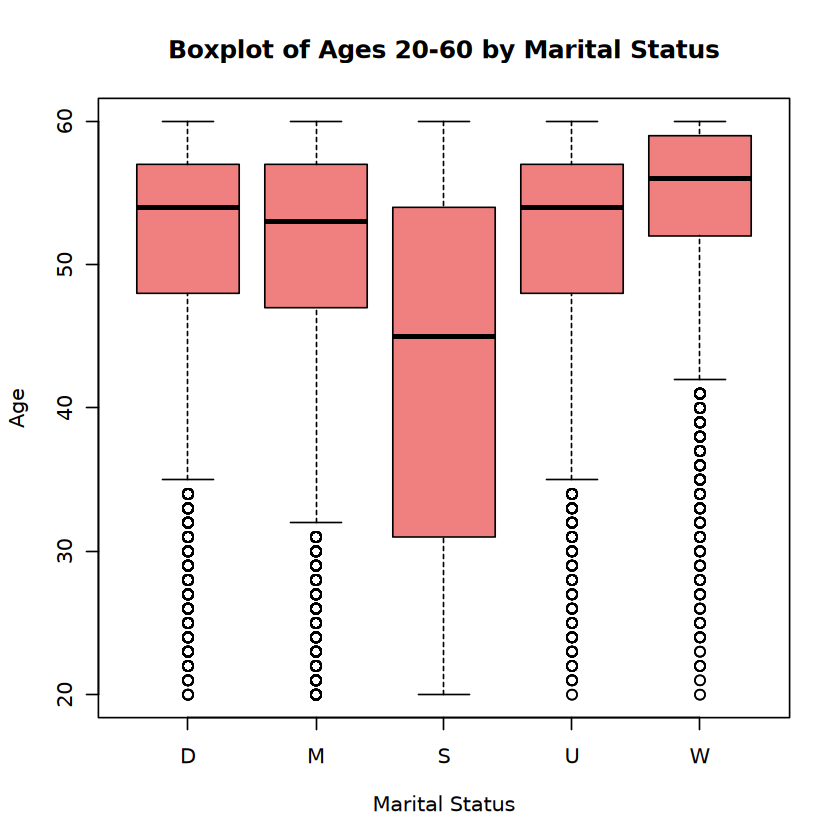

In [12]:
age_range_DF <- cleanDF[cleanDF$Age >= 20 & cleanDF$Age <= 60, ]
boxplot(Age ~ MaritalStatus, data = age_range_DF,
        main = "Boxplot of Ages 20-60 by Marital Status",
        xlab = "Marital Status",
        ylab = "Age",
        col = "lightcoral")

Focus on a specific age range and generate box plot for it

3.2 How the boxplot of a specific age range relates to the overall plot
- By focusing on a specific age range (e.g., 20–60), the boxplot highlights the central distribution of ages within the most common adult population.
- This makes it easier to compare marital statuses without being distracted by very young or very old ages, and it emphasizes differences that may be less visible in the full-age boxplot.
- Essentially, the age-range boxplot is a “zoomed-in” version that reveals finer details while still reflecting the trends seen in the overall plot.

## Question 4

In [13]:
cleanDF <- myDF[myDF$Age != 999, ]
married_widowed_DF <- cleanDF[cleanDF$MaritalStatus %in% c("M","W"), ]

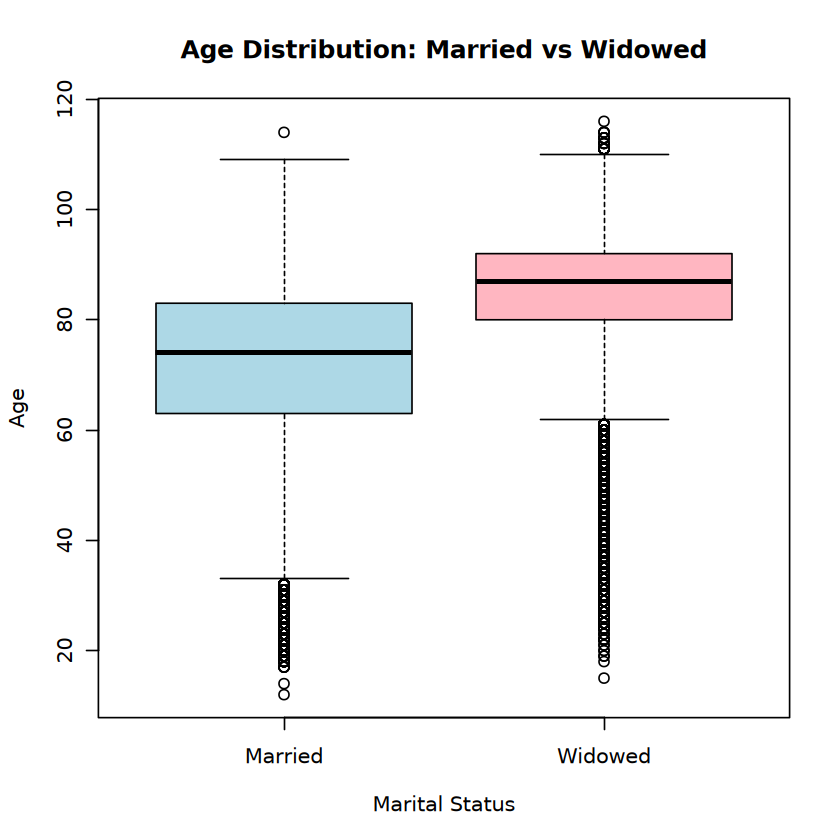

In [14]:
boxplot(Age ~ MaritalStatus, data = married_widowed_DF,
        main = "Age Distribution: Married vs Widowed",
        xlab = "Marital Status",
        ylab = "Age",
        col = c("lightblue","lightpink"),
        names = c("Married","Widowed"))

4.1 Married vs Widowed boxplot (all ages)
- The boxplot shows that widowed people tend to be older than married people at the time of death, which makes sense because older people are more likely to have lost a spouse.
- Married people have a wider age range, with some younger individuals, while widowed individuals cluster in higher ages.

In [15]:
age60_DF <- married_widowed_DF[married_widowed_DF$Age == 60, ]
age60_counts <- table(age60_DF$MaritalStatus)

Filter for age 60 and Married/Widowed

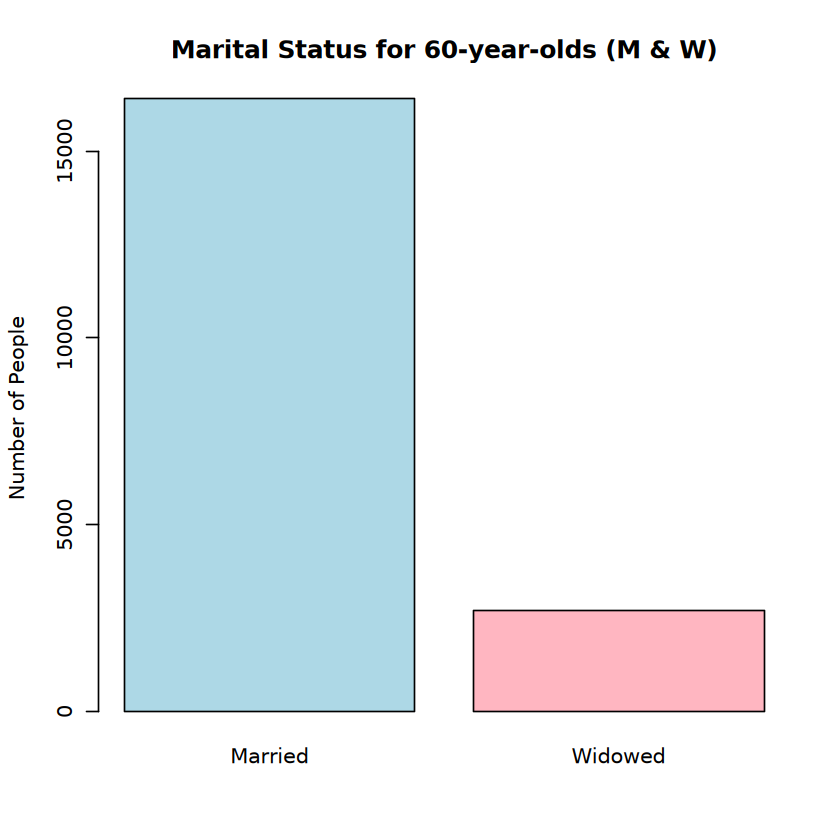

In [16]:
barplot(age60_counts,
        main = "Marital Status for 60-year-olds (M & W)",
        ylab = "Number of People",
        col = c("lightblue","lightpink"),
        names.arg = c("Married","Widowed"))

In [17]:
age65_DF <- married_widowed_DF[married_widowed_DF$Age == 65, ]
age65_counts <- table(age65_DF$MaritalStatus)

Filter for age 65 as comparison

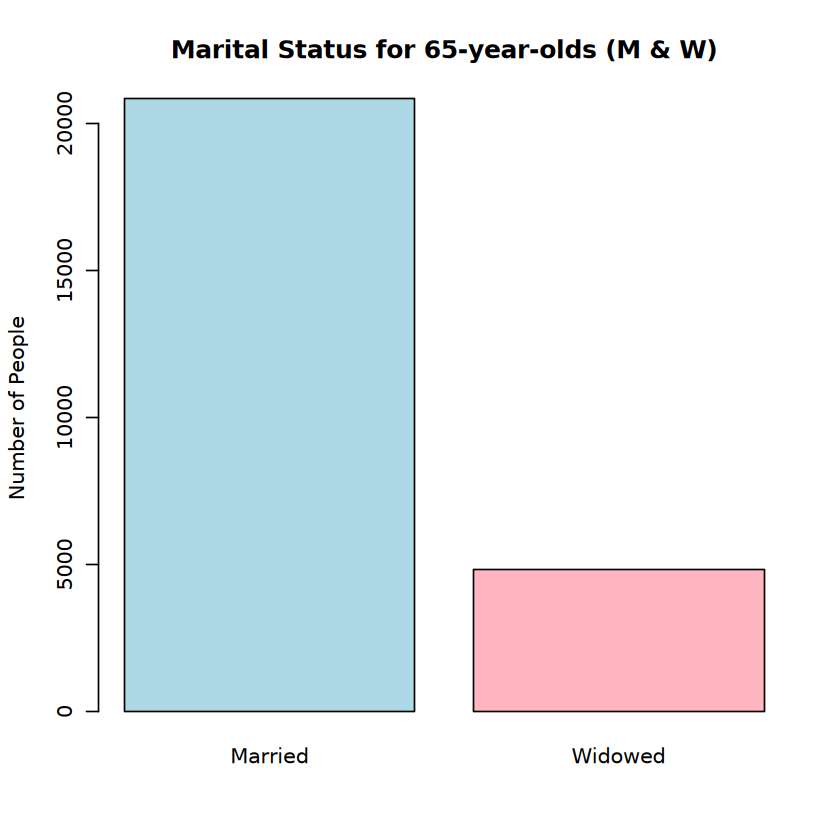

In [18]:
barplot(age65_counts,
        main = "Marital Status for 65-year-olds (M & W)",
        ylab = "Number of People",
        col = c("lightblue","lightpink"),
        names.arg = c("Married","Widowed"))

4.2 Barplots for 60-year-olds vs 65-year-olds (Married/Widowed)
- For 60-year-olds, most people are still married, with relatively few widowed individuals.
- At 65, the number of widowed people increases while married people slightly decrease.
- This suggests that as age increases, the proportion of widowed people grows, reflecting natural changes in marital status with age.

In [19]:
plot_age_bar <- function(age_value) {
  ageDF <- cleanDF[cleanDF$Age == age_value, ]
  counts <- table(ageDF$MaritalStatus)
  barplot(counts,
          main = paste("Marital Status Distribution for Age", age_value),
          ylab = "Number of People",
          col = rainbow(length(counts)))
}

Function to create barplots for any age

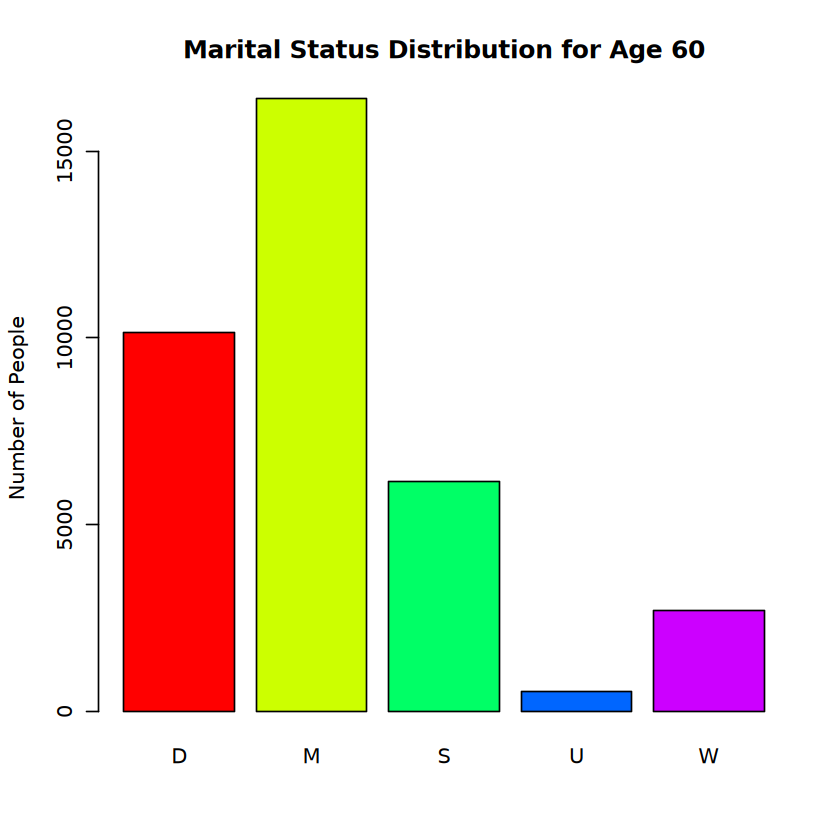

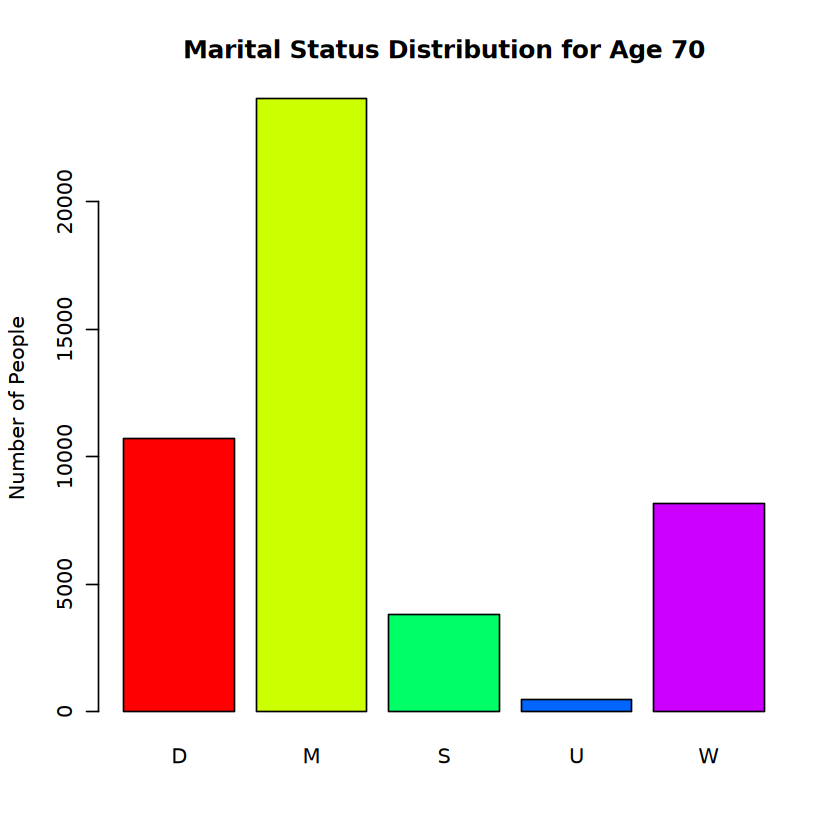

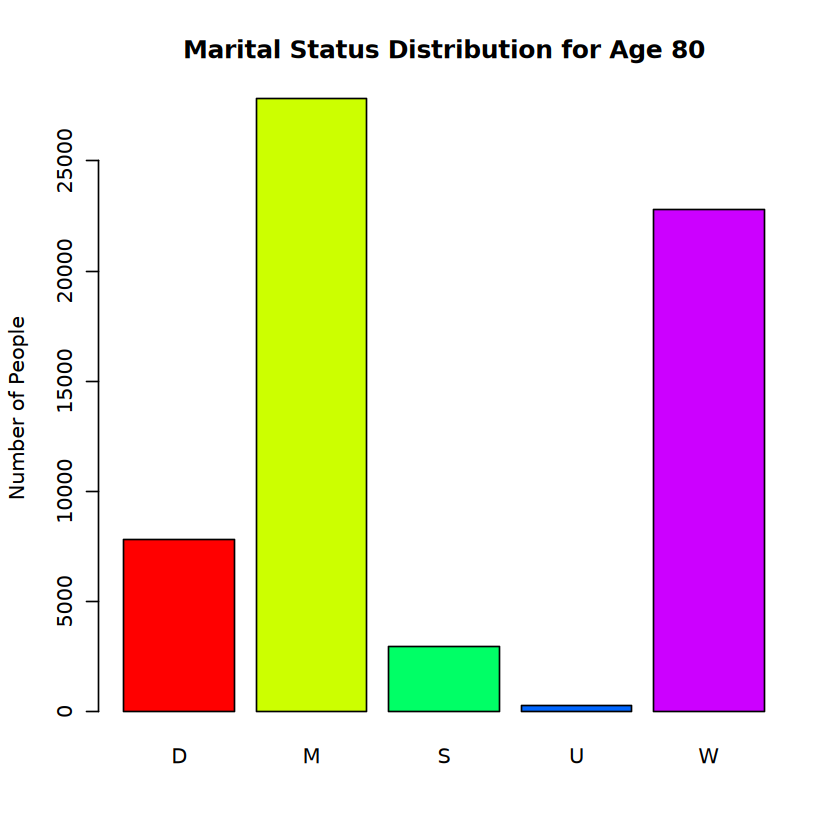

In [20]:
plot_age_bar(60)
plot_age_bar(70)
plot_age_bar(80)

4.3 Barplots for all marital statuses at ages 60, 70, 80
- 60-year-olds: Mostly married, small numbers of widowed and other statuses.
- 70-year-olds: Proportion of widowed individuals rises; married individuals decrease.
- 80-year-olds: Widowed is often the largest category; married is smaller, single or divorced categories are small.

Overall trend: As people age, the likelihood of being widowed increases, and the number of married individuals decreases. Single and divorced categories remain relatively low but present.

## Question 5

In [3]:
day_of_week_of_death <- read.csv("/anvil/projects/tdm/data/death_records/DayOfWeekOfDeath.csv")
myDF_merged <- merge(myDF, day_of_week_of_death, 
                     by.x = "DayOfWeekOfDeath", by.y = "Code", all.x = TRUE)

colnames(myDF_merged)[which(names(myDF_merged)=="Description")] <- "DayOfWeekName"

Merge myDF with the decoder to get day names and rename the new column for clarity

In [4]:
table(myDF_merged$DayOfWeekOfDeath, myDF_merged$DayOfWeekName)

   
    Friday Monday Saturday Sunday Thursday Tuesday Unknown Wednesday
  1      0      0        0 372388        0       0       0         0
  2      0 375854        0      0        0       0       0         0
  3      0      0        0      0        0  372792       0         0
  4      0      0        0      0        0       0       0    380526
  5      0      0        0      0   372464       0       0         0
  6 378949      0        0      0        0       0       0         0
  7      0      0   378070      0        0       0       0         0
  9      0      0        0      0        0       0     128         0

Create a table comparing numeric codes to day names

5.1 What does merge() do and how is it used here?
- merge() combines two datasets based on a shared key column.
- Here, it matches the numeric DayOfWeekOfDeath codes from DeathRecords.csv with their textual descriptions from DayOfWeekOfDeath.csv. This allows us to have a new column (DayOfWeekName) with readable day names instead of codes.

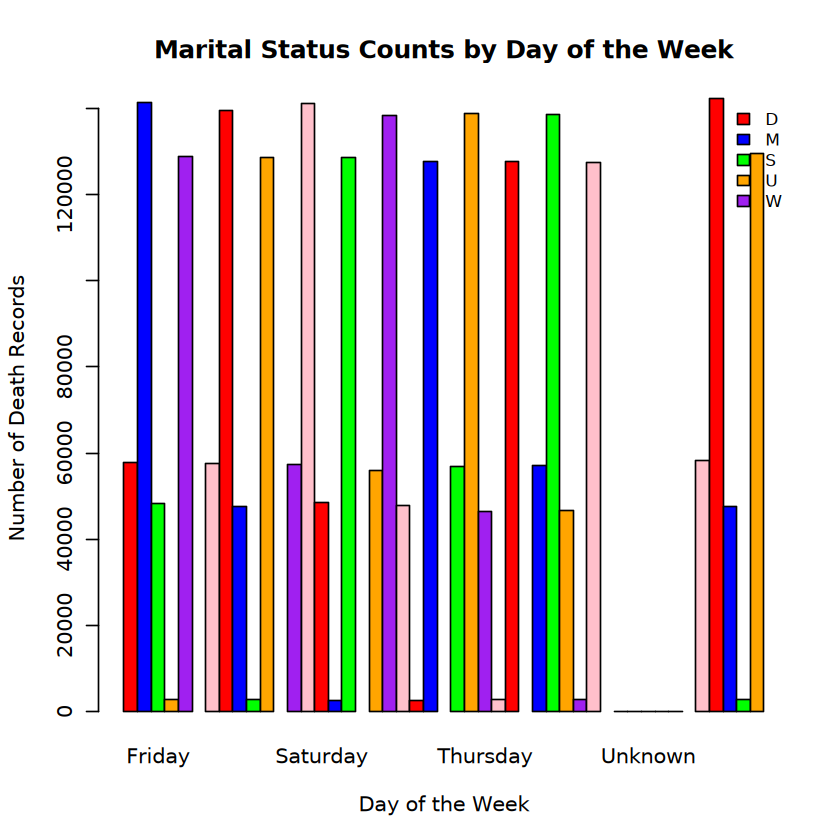

In [11]:
barplot(marital_day_table,
        beside = TRUE, 
        col = c("red","blue","green","orange","purple","pink"),
        main = "Marital Status Counts by Day of the Week",
        xlab = "Day of the Week",
        ylab = "Number of Death Records",
        legend.text = rownames(marital_day_table),
        args.legend = list(x = "topright", bty = "n", cex = 0.8))

In [13]:
myDF_filtered <- myDF_merged[!myDF_merged$DayOfWeekOfDeath %in% 9, ]
days_mf <- myDF_filtered[myDF_filtered$DayOfWeekName %in% c("Monday","Friday"), ]

First, remove any error days and then filter Monday and Friday

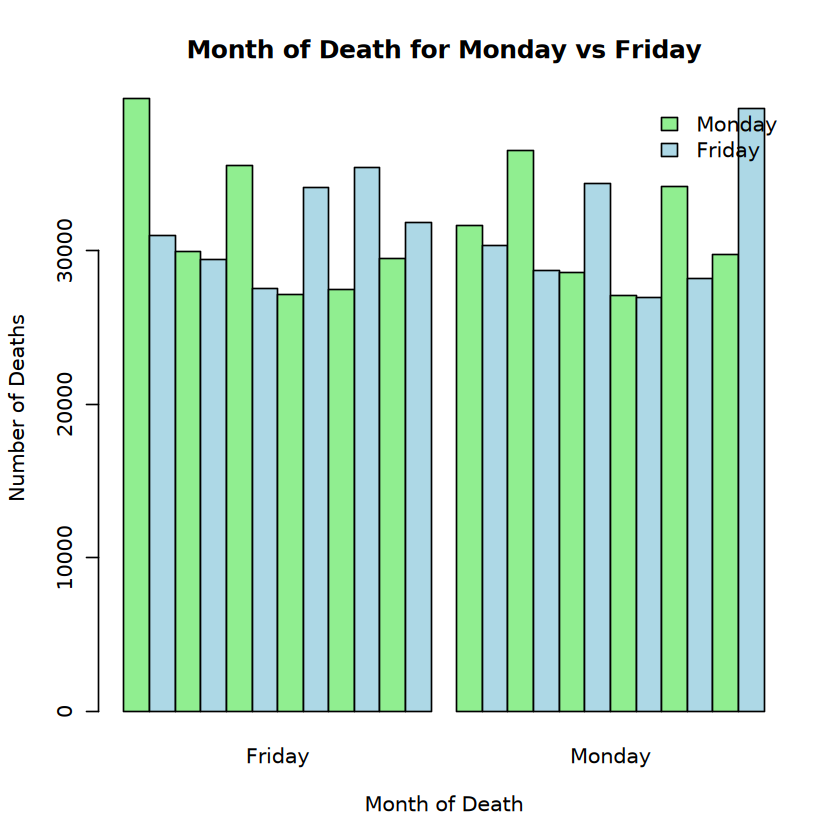

In [17]:
month_day_table <- table(days_mf$MonthOfDeath, days_mf$DayOfWeekName)
barplot(month_day_table,
        beside = TRUE,
        col = c("lightgreen","lightblue"),
        main = "Month of Death for Monday vs Friday",
        xlab = "Month of Death",
        ylab = "Number of Deaths",
        legend.text = c("Monday","Friday"),
        args.legend = list(x = "topright", bty = "n"))

Barplot for Monday vs Friday by month

In [20]:
month_marital_table <- table(myDF_merged$MonthOfDeath, myDF_merged$MaritalStatus)

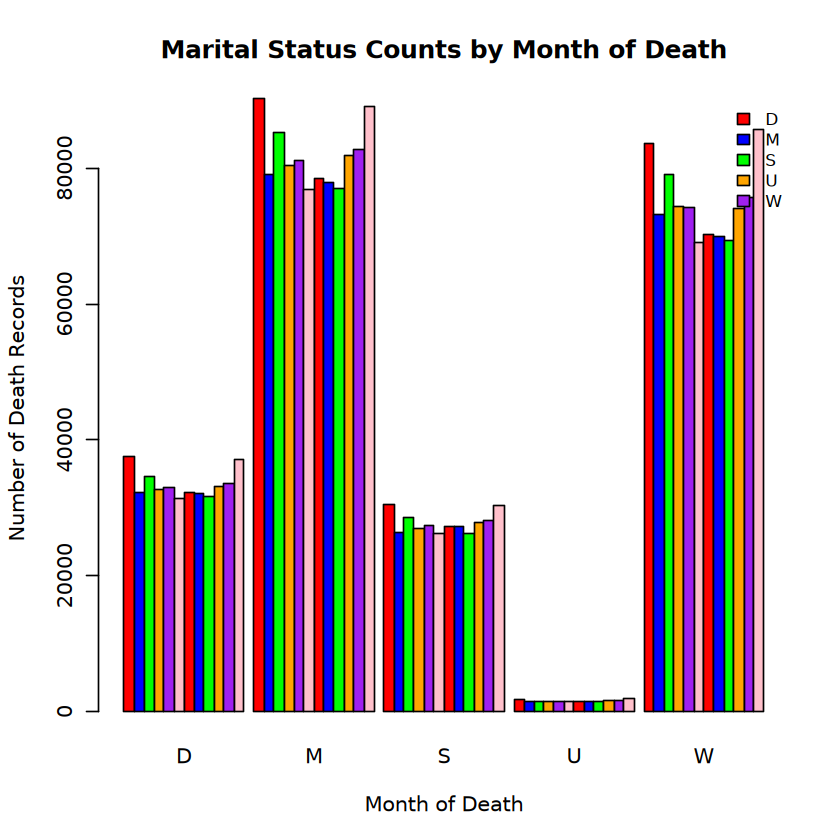

In [21]:
barplot(month_marital_table,
        beside = TRUE,
        col = c("red","blue","green","orange","purple","pink"),
        main = "Marital Status Counts by Month of Death",
        xlab = "Month of Death",
        ylab = "Number of Death Records",
        legend.text = colnames(month_marital_table),
        args.legend = list(x = "topright", bty = "n", cex = 0.8))

Barplot of MonthOfDeath vs MaritalStatus (all months)

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
